In [18]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATA_ROOT = Path("../data/raw/ebnerd_large")

train_beh_path = DATA_ROOT / "train" / "behaviors.parquet"
val_beh_path = DATA_ROOT / "validation" / "behaviors.parquet"

train_hist_path = DATA_ROOT / "train" / "history.parquet"
val_hist_path = DATA_ROOT / "validation" / "history.parquet"

In [11]:
behaviors = pd.read_parquet(train_beh_path)
behaviors.shape, behaviors.columns

history = pd.read_parquet(train_hist_path)
history.shape, history.columns

((788090, 5),
 Index(['user_id', 'impression_time_fixed', 'scroll_percentage_fixed',
        'article_id_fixed', 'read_time_fixed'],
       dtype='object'))

In [14]:
display(behaviors.head(3))
display(history.head(3))

,impression_id,article_id,impression_time,read_time,scroll_percentage,device_type,article_ids_inview,article_ids_clicked,user_id,is_sso_user,gender,postcode,age,is_subscriber,session_id,next_read_time,next_scroll_percentage
0,47727,NaN,2023-05-21 21:35:07,20.0,NaN,1,"[9482380, 9775183, 9744403, 9775297, 9774020, ...",[9775183],18293,False,NaN,NaN,NaN,False,265,34.0,100.0
1,47731,NaN,2023-05-21 21:32:33,13.0,NaN,1,"[9774557, 9774516, 9775331, 9775277, 9759966]",[9759966],18293,False,NaN,NaN,NaN,False,265,45.0,100.0
2,47736,NaN,2023-05-21 21:33:32,17.0,NaN,1,"[9759966, 9774557, 9775352, 9746360, 9772601, ...",[9774652],18293,False,NaN,NaN,NaN,False,265,78.0,100.0


,user_id,impression_time_fixed,scroll_percentage_fixed,article_id_fixed,read_time_fixed
0,10029,"[2023-04-28T06:16:57.000000, 2023-04-28T06:17:...","[23.0, 69.0, 27.0, nan, 47.0, 38.0, 100.0, 12....","[9735579, 9739888, 9739471, 9739864, 9738441, ...","[28.0, 24.0, 11.0, 107.0, 8.0, 7.0, 20.0, 5.0,..."
1,10033,"[2023-04-27T11:11:32.000000, 2023-04-27T11:12:...","[33.0, 41.0, 33.0, 100.0, 68.0, 38.0, 1.0, 58....","[9738139, 9738263, 9738139, 9738760, 9738777, ...","[2.0, 2.0, 718.0, 18.0, 26.0, 78.0, 3.0, 11.0,..."
2,10034,"[2023-04-30T09:46:57.000000, 2023-04-30T09:47:...","[nan, 88.0, 27.0, nan, 23.0, 100.0, 100.0, 22....","[9742693, 9742686, 9744016, 9743818, 9744922, ...","[21.0, 103.0, 28.0, 0.0, 5.0, 34.0, 14.0, 14.0..."


## Unique users

In [16]:
print("unique users:", behaviors["user_id"].nunique())

unique users: 788090


## Events per user

In [17]:
events_per_user = behaviors.groupby("user_id").size()
events_per_user.describe()

count    788090.000000
mean         15.307757
std          17.670011
min           1.000000
25%           3.000000
50%           9.000000
75%          21.000000
max         250.000000
dtype: float64

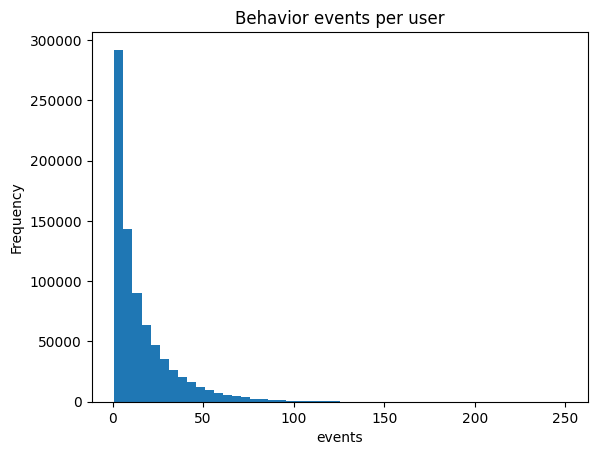

In [19]:
events_per_user.plot.hist(bins=50)
plt.title("Behavior events per user")
plt.xlabel("events")
plt.show()

## Impressions per event

In [20]:
behaviors["n_impressions"] = behaviors["article_ids_inview"].apply(len) 
behaviors["n_impressions"].describe()

count    1.206389e+07
mean     1.109183e+01
std      7.660769e+00
min      5.000000e+00
25%      6.000000e+00
50%      8.000000e+00
75%      1.300000e+01
max      1.000000e+02
Name: n_impressions, dtype: float64

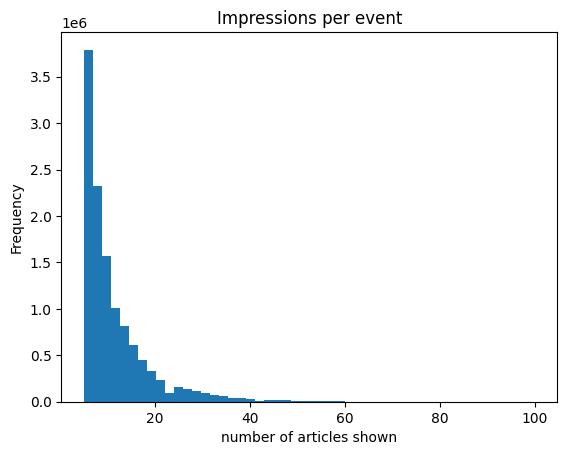

In [21]:
behaviors["n_impressions"].plot.hist(bins=50)
plt.title("Impressions per event")
plt.xlabel("number of articles shown")
plt.show()

## Click per event

In [22]:
behaviors["n_clicks"] = behaviors["article_ids_clicked"].apply(len)

behaviors["n_clicks"].value_counts()

n_clicks
1     12004156
2        53705
3         3566
4         1258
5          597
6          358
7          209
8           28
9           11
10           2
Name: count, dtype: int64

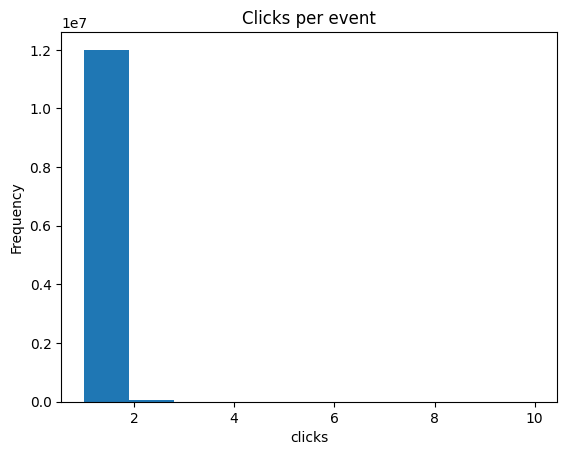

In [23]:
behaviors["n_clicks"].plot.hist(bins=10)
plt.title("Clicks per event")
plt.xlabel("clicks")
plt.show()

## CTR (click-through rate)

In [24]:
behaviors["ctr"] = behaviors["n_clicks"] / behaviors["n_impressions"]

behaviors["ctr"].describe()

count    1.206389e+07
mean     1.211824e-01
std      5.465389e-02
min      1.000000e-02
25%      7.692308e-02
50%      1.250000e-01
75%      1.666667e-01
max      6.000000e-01
Name: ctr, dtype: float64

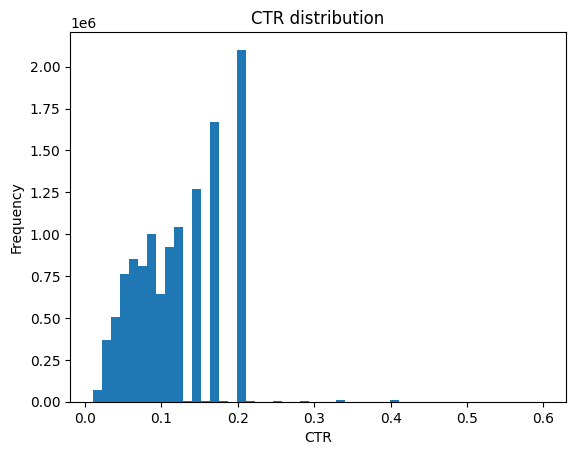

In [25]:
behaviors["ctr"].plot.hist(bins=50)
plt.title("CTR distribution")
plt.xlabel("CTR")
plt.show()

## Subscriber vs non-subscriber

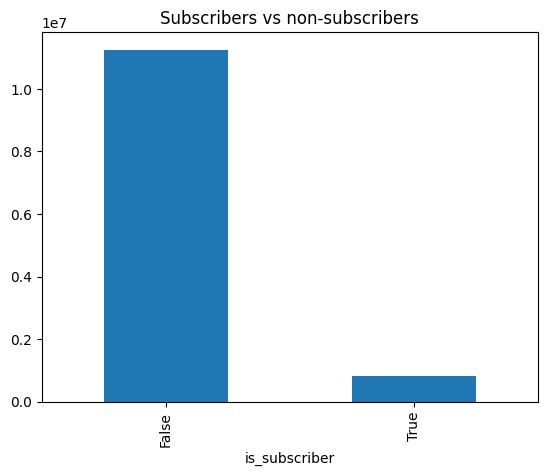

In [26]:
behaviors["is_subscriber"].value_counts().plot.bar()

plt.title("Subscribers vs non-subscribers")
plt.show()

## Read time

In [27]:
behaviors["read_time"].describe()

count    1.206389e+07
mean     4.401300e+01
std      9.175906e+01
min      0.000000e+00
25%      1.100000e+01
50%      2.100000e+01
75%      4.400000e+01
max      1.800000e+03
Name: read_time, dtype: float64

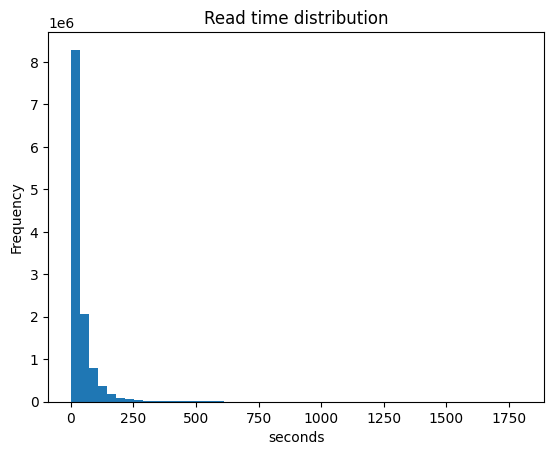

In [28]:
behaviors["read_time"].plot.hist(bins=50)

plt.title("Read time distribution")
plt.xlabel("seconds")
plt.show()

## Session analysis

In [30]:
sessions_per_user = behaviors.groupby("user_id")["session_id"].nunique()

sessions_per_user.describe()

count    788090.000000
mean          7.901971
std           7.951488
min           1.000000
25%           2.000000
50%           5.000000
75%          11.000000
max          94.000000
Name: session_id, dtype: float64

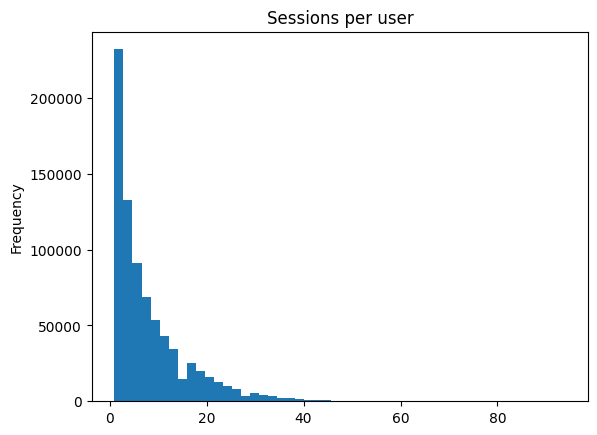

In [31]:
sessions_per_user.plot.hist(bins=50)

plt.title("Sessions per user")
plt.show()